<a href="https://colab.research.google.com/github/spentapa3-lgtm/deeplearning-/blob/main/RNN_for_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.7444 - loss: 0.5114 - val_accuracy: 0.8204 - val_loss: 0.4112
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8695 - loss: 0.3199 - val_accuracy: 0.8488 - val_loss: 0.3631
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.9046 - loss: 0.2441 - val_accuracy: 0.8042 - val_loss: 0.4235
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.9414 - loss: 0.1629 - val_accuracy: 0.8250 - val_loss: 0.4333
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.9708 - loss: 0.0914 - val_accuracy: 0.8464 - val_loss: 0.4723
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8428 - loss: 0.5019
Test Accuracy: 0.8428000211715698


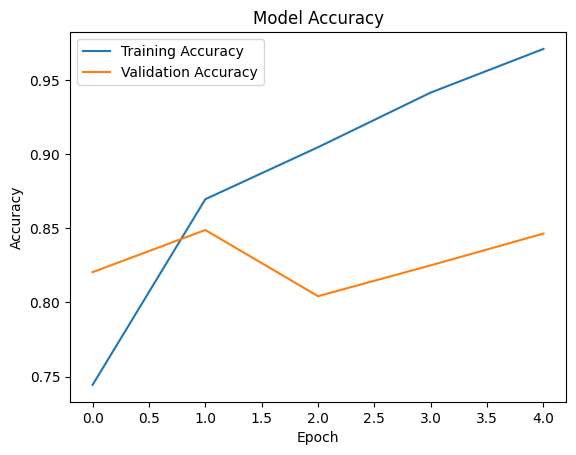

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=32))

model.add(SimpleRNN(32))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()